# Determining the Optimal Number of Hidden Layers and Neurons for an Artificial Neural Network (ANN)

This can be challenging and often requires experimentation. However, there are some guidelines and methods that can help you in making an informed decision:

- **Start Simple:** Begin with a simple architecture and gradually increase complexity if needed.

- **Grid Search / Random Search:** Use grid search or random search to try different architectures.

- **Cross-Validation:** Use cross-validation to evaluate the performance of different architectures.

- **Heuristics and Rules of Thumb:** Some heuristics and empirical rules can provide starting points, such as:
  - The number of neurons in the hidden layer should be between the size of the input layer and the size of the output layer.
  - A common practice is to start with 1–2 hidden layers.

In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import pickle 

In [76]:
data = pd.read_csv('Churn_Modelling.csv')
data = data.drop(['RowNumber','CustomerId','Surname'],axis=1)

label_encoder_gender = LabelEncoder()
data['Gender'] = label_encoder_gender.fit_transform(data['Gender'])

onehot_encoder_geo = OneHotEncoder(handle_unknown='ignore')
geo_encoded = onehot_encoder_geo.fit_transform(data[['Geography']]).toarray()
geo_encoded_df = pd.DataFrame(geo_encoded, columns=onehot_encoder_geo.get_feature_names_out())

data = pd.concat([data.drop('Geography', axis=1), geo_encoded_df], axis=1)

X = data.drop('Exited', axis=1)
y = data['Exited']

In [77]:
data.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [78]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [80]:
# Save encoders and scaler for later use

with open('label_encoder_gender.pkl','wb') as file:
    pickle.dump(label_encoder_gender,file)

with open('onehot_encoder_geo.pkl','wb') as file:
    pickle.dump(onehot_encoder_geo,file)

with open('scaler.pkl','wb') as file:
    pickle.dump(scaler,file)

In [81]:
## Define a function to create the model and try different parameters(KerasClassifier)

def create_model(neurons=32,layers=1):
    model = Sequential()
    model.add(Dense(neurons,activation='relu',input_shape=(X_train.shape[1],)))

    for _ in range(layers-1):
        model.add(Dense(neurons,activation='relu'))
    
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
    
    return model

In [82]:
# Create a keras classifier 
model = KerasClassifier(neurons=32, layers=1, build_fn=create_model, epochs=50, batch_size=10, verbose=0)

In [83]:
# Define the grid search parameters
param_grid = {
    'neurons':[16,32,64,128],
    'layers': [1,2],
    'epochs' : [50,100]
}

In [84]:
import numpy as np
np.isnan(X_train).sum()

np.int64(0)

In [85]:
# perform grid search
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(X_train, y_train)

# Print the best parameters
print('Best: %f using %s' % (grid_result.best_score_, grid_result.best_params_))

c:\Users\bhika\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\bhika\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best: 0.855999 using {'epochs': 100, 'layers': 1, 'neurons': 32}


In [86]:
best_model = Sequential([
    Dense(32 ,activation='relu' ,input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

c:\Users\bhika\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [87]:
best_model.compile(optimizer='adam',loss=['binary_crossentropy'],metrics=['accuracy'])

In [94]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history = best_model.fit(X_train,y_train,epochs=100,batch_size=32,validation_data=(X_test,y_test),callbacks=[early_stop])

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8698 - loss: 0.3105 - val_accuracy: 0.8655 - val_loss: 0.3341
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8715 - loss: 0.3097 - val_accuracy: 0.8615 - val_loss: 0.3350
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8719 - loss: 0.3101 - val_accuracy: 0.8660 - val_loss: 0.3341
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8715 - loss: 0.3102 - val_accuracy: 0.8640 - val_loss: 0.3355
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8714 - loss: 0.3095 - val_accuracy: 0.8640 - val_loss: 0.3351
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8720 - loss: 0.3096 - val_accuracy: 0.8640 - val_loss: 0.3350
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8717 - loss: 0.3099 - val_accuracy: 0.8645 - val_loss: 0.3340
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8733 - loss: 0.3091 - val_accu

In [95]:
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict(X_test)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step
AUC Score: 0.8608


In [96]:
from sklearn.metrics import classification_report

y_pred = (best_model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['Stay','Churn']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
              precision    recall  f1-score   support

        Stay       0.88      0.96      0.92      1607
       Churn       0.74      0.48      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [97]:
from sklearn.metrics import classification_report

y_pred = (best_model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['Stay','Churn']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step
              precision    recall  f1-score   support

        Stay       0.88      0.96      0.92      1607
       Churn       0.74      0.48      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



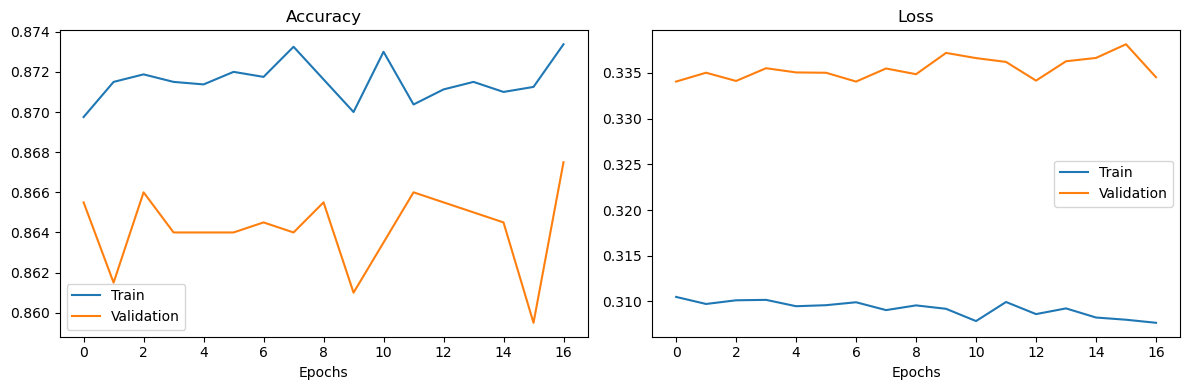

In [98]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()